# Machine learning model

## Setup

### Imports and functions

In [1]:
import pandas as pd
import glob #For combining individual files into one dataframe
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
def load_parquet(path_pattern: str, engine='fastparquet') -> pd.DataFrame:
    """
    Loads parquet file(s).
    Supports glob patterns like "*.parquet.gzip".
    
    Args:
        path_pattern: File path or glob pattern.
        engine: Parquet engine.

    Returns:
        Single DataFrame, concatenated if multiple files.
    """

    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No files found matching: {path_pattern}")
    
    dfs = [pd.read_parquet(f, engine=engine) for f in files]
    df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
    print(f"Loaded {len(df):,} rows from {len(dfs)} files matching \"{path_pattern}\"")
    
    return df

### Load AIS data and voyage META data
We're only interested in arrivals to Valencia, as it's there we aim to optimize berth allocation and scheduling, thus we can forego departures.

In [3]:
arrivals_ais_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip")
arrivals_ais_meta_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip")

Loaded 3,311,442 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip"
Loaded 43,352 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip"


## Exploratory data analysis

### Inspect AIS data

In [4]:
arrivals_ais_data.shape

(3311442, 50)

In [5]:
arrivals_ais_data.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month'],
      dtype='object')

In [6]:
arrivals_ais_data.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,capacity_liquid_gas,capacity_passenger,capacity_liquid_oil,commercial_size_class,vessel_type_details,draught_max,draught_min,capacity_nt,vid_prefix,month
0,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:11:09,UNDEFINED,False,-0.330460,39.426970,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
1,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:29:09,UNDEFINED,False,-0.330560,39.426960,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
2,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:50:10,UNDEFINED,False,-0.330510,39.426940,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,0,0,0,HANDYSIZE,Bulk Carrier,10.6,4.8,10500,01,2024-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,0,0,0,HANDYSIZE,Bulk Carrier,10.6,4.8,10500,01,2024-01


### Inspect voyage META data

In [7]:
arrivals_ais_meta_data.shape

(43352, 17)

In [8]:
arrivals_ais_meta_data.columns

Index(['voyage_id', 'mmsi', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude',
       'prev_voyage_id', 'next_voyage_id', 'departed_port_call_id',
       'arrived_port_call_id', 'duration', 'arrival_country', 'arrival_date'],
      dtype='object')

In [9]:
arrivals_ais_meta_data.head()

,voyage_id,mmsi,departure_time,departure_locode,departure_latitude,departure_longitude,arrival_time,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,f4a7d707-95c8-4e3f-93f4-c6000e57853a,224208000,2024-01-15 22:57:24,ESVLC,39.441430,-0.317925,2024-01-15 23:58:36,ESVLC,39.442105,-0.317382,f49ebf4b-71a0-4c81-8317-59d5930c79ed,864c813c-e3d1-4627-9088-750d4bcb9f96,,,3672.0,ES,2024-01-16
1,597c19e1-449b-49a3-9044-62788862926a,225952430,2024-01-15 22:54:55,ESVLC,39.421110,-0.329000,2024-01-16 00:00:00,ESVLC,39.424800,-0.327170,b228aff6-44bb-479c-8cef-ea39fd47b4f0,f01811e2-e6ce-49e6-8877-60d7b326d46e,,,3905.0,ES,2024-01-16
2,ec23c291-f150-4314-a4b7-5834e47c7f7a,255915587,2024-01-15 22:22:37,ESVLC,39.394322,-0.275112,2024-01-16 00:33:06,ESVLC,39.434488,-0.327693,776e4362-e3f9-47ea-97d4-df89891f1204,03f0aad7-0ec9-4f83-a8d4-335b75906a29,,,7829.0,ES,2024-01-16
3,98074eeb-fe2a-4478-8e51-8c9ea2aed4f6,205345130,2024-01-15 22:53:39,ESVLC,39.430230,-0.332620,2024-01-16 00:29:40,ESVLC,39.430240,-0.332640,2737f7cd-015c-45bc-9bd4-d0f2134b917c,e20b07a6-59b9-47f0-92af-c91892a34149,,,5761.0,ES,2024-01-16
4,4c617e21-5ff2-423e-9c81-d4e3b61986dd,255806500,2024-01-15 11:17:21,ESBCN,41.310288,2.150347,2024-01-16 00:39:26,ESVLC,39.439080,-0.325422,115375ca-6147-4c60-910f-13ef7da40f06,2d6446e8-b61b-4da4-aefe-9d949aaac8ec,,,48125.0,ES,2024-01-16


#### Check if the voyage META data contains any duplicates

In [10]:
dupe_mask = arrivals_ais_meta_data["voyage_id"].duplicated(keep="first")
dupes = arrivals_ais_meta_data[dupe_mask].copy()

print(f"Duplicated rows: {len(dupes)}")

if (len(dupes)):
    dupes.head()

Duplicated rows: 0


### Merging AIS data with voyage META data
The AIS data is the dynamic, continuously transmitted AIS data samples from vessels, whereas the META data represents the static information of the voyage.
This means the META data includes e.g. the duration of the voyage, i.e. our truth values for supervised ML.
Thus we merge them into a single DataFrame.

In [11]:
ais_meta_merged = arrivals_ais_data.merge(
    arrivals_ais_meta_data,
    on="voyage_id",
    how="left",
    suffixes=("_ais", "_meta"), # column name suffix if both DataFrames contain the same column
)

#### Check how many AIS data samples have voyage META data

In [12]:
has_meta_pct = ais_meta_merged["arrival_time"].notna().mean() * 100
print(f"{has_meta_pct:.2f}% of AIS data samples have META data")

100.00% of AIS data samples have META data


In [13]:
ais_meta_merged.shape

(3311442, 66)

In [14]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'mmsi_meta', 'departure_time',
       'departure_locode', 'departure_latitude', 'departure_longitude',
       'arrival_time', 'arrival_locode', 'arrival_latitude',
  

In [15]:
ais_meta_merged.head()

,voyage_id,voyage_status,mmsi_ais,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:11:09,UNDEFINED,False,-0.330460,39.426970,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
1,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:29:09,UNDEFINED,False,-0.330560,39.426960,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
2,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:50:10,UNDEFINED,False,-0.330510,39.426940,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01


### Check if mmsi_ais and mmsi_meta are equal
If so, drop mmsi_meta column and rename mmsi_ais to mmsi

In [16]:
same_mmsi_mask = ais_meta_merged["mmsi_ais"] == ais_meta_merged["mmsi_meta"]
pct_same = same_mmsi_mask.mean() * 100
print(f"mmsi_ais and mmsi_meta match in {pct_same:.2f}% of merged rows")


mmsi_ais and mmsi_meta match in 100.00% of merged rows


In [17]:
ais_meta_merged = ais_meta_merged.drop("mmsi_meta", axis="columns")
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longit

In [18]:
ais_meta_merged.rename(columns={"mmsi_ais": "mmsi"}, inplace=True)

In [19]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

### Determining the actual time of arrival

#### To determine the actual time of arrival (ATA) we will use a simplistic definition of "if vessel is in bounding box, it's ready to berthe".

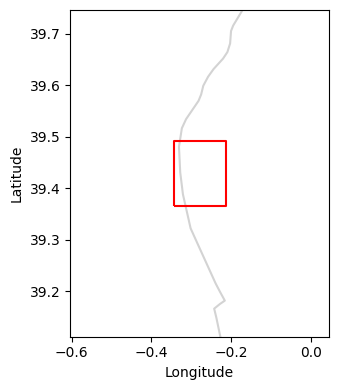

In [66]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

coastline = gpd.read_file("./data/ne_10m_coastline/ne_10m_coastline.shp")
max_lat = 39.492119
min_lat = 39.3653539
min_lon = -0.343666
max_lon = -0.213547

bbox = box(min_lon, min_lat, max_lon, max_lat)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs="EPSG:4326") # Coordinat Reference System, WGS84 lat/long in degrees

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
coastline.plot(ax=ax, color="lightgrey")
bbox_gdf.boundary.plot(ax=ax, edgecolor="red")

# Add padding around bbox (200%)
pad_lon = (max_lon - min_lon) * 2
pad_lat = (max_lat - min_lat) * 2
ax.set_xlim(min_lon - pad_lon, max_lon + pad_lon)
ax.set_ylim(min_lat - pad_lat, max_lat + pad_lat)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


## Pre-processing

### Defining the population

#### Filter out non-commercial vessels

In [21]:
ais_meta_merged["vessel_type_details"].unique()

array(['', 'Bulk Carrier', 'General Dry Cargo', 'Chemical Tanker',
       'Container Ship', 'Offshore', 'Tanker', 'Roll-on Roll-off',
       'Vehicle/Passenger', 'Pure Car Carrier', 'Miscellaneous',
       'Passenger Ship', 'LPG Carrier'], dtype=object)

In [22]:
ais_meta_merged["vessel_type_details"].value_counts(normalize=True).mul(100).round(2)

vessel_type_details
                     64.83
Container Ship       23.16
Roll-on Roll-off      2.51
Chemical Tanker       2.12
Tanker                1.91
General Dry Cargo     1.32
Pure Car Carrier      1.32
Bulk Carrier          1.26
Offshore              1.22
Vehicle/Passenger     0.24
Passenger Ship        0.06
Miscellaneous         0.05
LPG Carrier           0.01
Name: proportion, dtype: float64

In [23]:
VALID_VESSEL_TYPES = ["Bulk Carrier", "General Dry Cargo", "Chemical Tanker", "Container Ship", "Tanker", "LPG Carrier", "Pure Car Carrier", "Roll-on Roll-off"]

mask = ais_meta_merged["vessel_type_details"].isin(VALID_VESSEL_TYPES)
cargo_ais_meta_merged = ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
10,01f80139-2bd0-4ff0-8cdd-33c0064ba220,PENDING_DEPARTURE,577005000,2024-01-29 21:02:50,MOORED,False,-0.321315,39.445050,178.199997,111,...,ESVLC,39.445048,-0.321325,10b4dad4-687a-48c3-ad7d-0d79adea92e7,a6910090-2954-47dc-89ad-22f0139013d7,,,3611.0,ES,2024-01-31


#### Filter out voyages with invalid voyage status

In [24]:
cargo_ais_meta_merged["voyage_status"].unique()

array(['STOPPED', 'PENDING_DEPARTURE', 'UNDER_WAY', 'COMPLETED'],
      dtype=object)

In [25]:
cargo_ais_meta_merged["voyage_status"].value_counts(normalize=True).mul(100).round(2)

voyage_status
UNDER_WAY            51.19
PENDING_DEPARTURE    32.44
STOPPED              15.63
COMPLETED             0.74
Name: proportion, dtype: float64

In [26]:
VALID_VOYAGE_STATUSES = ["UNDER_WAY", "STOPPED"]

mask = cargo_ais_meta_merged["voyage_status"].isin(VALID_VOYAGE_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
22,029a4b25-666a-41dd-ad98-f3dd0b467c92,UNDER_WAY,620331000,2024-01-01 05:48:00,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,277.799988,274,...,ESVLC,39.444928,-0.32074,26d91f33-f8bb-4ea2-8a89-50cefa59059c,a314bc7a-6bfb-4968-9e93-fec84a4bffa6,,,664483.0,ES,2024-01-03


#### Filter out voyages with missing MMSI

In [27]:
voyages_with_valid_mmsi_pct = cargo_ais_meta_merged["mmsi"].notna().mean() * 100
print(f"Voyages with valid MMSI: {voyages_with_valid_mmsi_pct:.2f}%")

Voyages with valid MMSI: 100.00%


No need to remove missing MMSI entries.

#### Filter out AIS data past actual time of arrival to isolate the voyage from the "waiting to be berthed" stage

We observe that draught, length, width, capacity_dwt, capacity_gw, capacity_teu, capacity_nt are all highly correlated.<br>
Perhaps we can combine these features into a singular feature.

In [69]:
max_lat = 39.492119
min_lat = 39.3653539
min_lon = -0.343666
max_lon = -0.213547

in_bbox = (
    (cargo_ais_meta_merged["latitude"].between(min_lat, max_lat)) &
    (cargo_ais_meta_merged["longitude"].between(min_lon, max_lon))
)

cargo_ais_meta_merged["in_bbox"] = in_bbox

In [70]:
cargo_ais_meta_merged["in_bbox"].sample(10)

2169347    False
548958     False
393039      True
2810731    False
3112008    False
2611485     True
3106286    False
2892098    False
2102565    False
1532003     True
Name: in_bbox, dtype: bool

In [ ]:
cargo_ais_meta_merged.iloc[359223]

voyage_id                eb49562c-a04d-4683-92fa-55d24f957a08
voyage_status                                       UNDER_WAY
mmsi                                                636020515
pos_timestamp                             2024-06-10 04:34:57
navigation_status                     UNDER_WAY_USING_ENGINES
position_accuracy                                       False
longitude                                            0.045292
latitude                                            38.232645
course_over_ground                                  34.900002
true_heading                                               36
timestamp_seconds                                          54
raim                                                    False
rate_of_turn                                              0.0
speed_over_ground                                        10.9
pos_source                                              SPIRE
ship_type                                                  70
position

Above we see that voyage_status: STOPPED, navigation_status: AT_ANCHOR, in_bbox: True, yet tta_hours: 42.156111.
This means the arrival_time is when it HAS berthed and not when it arrived outside the harbor and is waiting for a berthing spot.

Trim all remaining data points after in_bbox becomes true

In [ ]:
# Sort by voyage and time first
df = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"])

# For each voyage, find the first index where in_bbox is True
first_in = (
    df[df["in_bbox"]]
    .groupby("voyage_id")["pos_timestamp"]
    .min()
    .rename("first_in_bbox_time")
)

# Join back to df
df = df.merge(first_in, on="voyage_id", how="left")

# Keep rows where:
# - Either the voyage never enters bbox (first_in_bbox_time is NaT)
# - Or timestamp <= first_in_bbox_time
mask_keep = (
    df["first_in_bbox_time"].isna() |
    (df["pos_timestamp"] <= df["first_in_bbox_time"])
)

df_trimmed = df[mask_keep].copy()
df_trimmed.head()

Now check if the same voyage has multiple data points where in_bbox is true

In [ ]:
rows = df_trimmed[
    (df_trimmed["voyage_id"] == "dd5793e3-5e49-4ab5-b25e-0e42949d848b")
    & (df_trimmed["in_bbox"])
]

rows

Its in the box but still under_way_using engines (navigation_status).
Lets try to get the first data point where navigation_status = AT_ANCHOR

In [ ]:
df2 = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"])
first_anchor = (
    df2[df2["navigation_status"] == "AT_ANCHOR"]
    .groupby("voyage_id")["pos_timestamp"]
    .min()
    .rename("first_anchor_time")
)
df2 = df2.merge(first_anchor, on="voyage_id", how="left")

mask_keep = (
    df2["first_anchor_time"].isna() |
    (df2["pos_timestamp"] <= df2["first_anchor_time"])
)

df_trimmed_anchor = df2[mask_keep].copy()
df_trimmed_anchor.head()

In [ ]:
rows2 = df_trimmed_anchor[
    (df_trimmed_anchor["voyage_id"] == "dd5793e3-5e49-4ab5-b25e-0e42949d848b")
    & (df_trimmed_anchor["first_anchor_time"].notna())
]

rows2.sort_values("pos_timestamp").tail(1)

#### Filter out voyages with invalid navigation statuses

In [28]:
cargo_ais_meta_merged["navigation_status"].unique()

array(['AT_ANCHOR', 'UNDER_WAY_USING_ENGINES', 'MOORED',
       'NOT_UNDER_COMMAND', 'CONSTRAINED_BY_HER_DRAUGHT',
       'UNDER_WAY_SAILING', 'RESTRICTED_MANEUVERABILITY', 'UNDEFINED',
       'AGROUND', 'PUSHING_AHEAD_OR_TOWING_ALONGSIDE',
       'ENGAGED_IN_FISHING'], dtype=object)

In [29]:
cargo_ais_meta_merged["navigation_status"].value_counts(normalize=True).mul(100).round(2)

navigation_status
UNDER_WAY_USING_ENGINES              80.81
AT_ANCHOR                            16.11
MOORED                                2.41
UNDER_WAY_SAILING                     0.41
NOT_UNDER_COMMAND                     0.14
RESTRICTED_MANEUVERABILITY            0.06
CONSTRAINED_BY_HER_DRAUGHT            0.04
UNDEFINED                             0.01
AGROUND                               0.01
PUSHING_AHEAD_OR_TOWING_ALONGSIDE     0.00
ENGAGED_IN_FISHING                    0.00
Name: proportion, dtype: float64

In [30]:
VALID_NAVIGATION_STATUSES = [
       'UNDER_WAY_USING_ENGINES', 'MOORED', 'AT_ANCHOR',
       'CONSTRAINED_BY_HER_DRAUGHT', 'UNDER_WAY_SAILING',
       'RESTRICTED_MANEUVERABILITY',
       'PUSHING_AHEAD_OR_TOWING_ALONGSIDE']

mask = cargo_ais_meta_merged["navigation_status"].isin(VALID_NAVIGATION_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
22,029a4b25-666a-41dd-ad98-f3dd0b467c92,UNDER_WAY,620331000,2024-01-01 05:48:00,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,277.799988,274,...,ESVLC,39.444928,-0.32074,26d91f33-f8bb-4ea2-8a89-50cefa59059c,a314bc7a-6bfb-4968-9e93-fec84a4bffa6,,,664483.0,ES,2024-01-03


In [31]:
cargo_ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

### Outlier detection and removal

#### Duration

In [32]:
cargo_ais_meta_merged["duration"].describe().div(60).round(2)

count     12372.25
mean      15269.29
std       18127.60
min           2.00
25%        2623.68
50%        6950.63
75%       22874.08
max      187349.28
Name: duration, dtype: float64

In [33]:
lower_q = 0.01
upper_q = 0.99

q_low  = cargo_ais_meta_merged["duration"].quantile(lower_q)
q_high = cargo_ais_meta_merged["duration"].quantile(upper_q)

mask = (cargo_ais_meta_merged["duration"] >= q_low) & (cargo_ais_meta_merged["duration"] <= q_high)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask]

In [34]:
cargo_ais_meta_merged["duration"].describe().div(60).round(2)

count    12133.35
mean     14562.39
std      15692.05
min         62.00
25%       2663.43
50%       6950.73
75%      22669.48
max      66623.32
Name: duration, dtype: float64

#### SOG

In [35]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    728001.000000
mean         10.538102
std           6.944221
min           0.000000
25%           2.100000
50%          12.300000
75%          16.100000
max         102.300003
Name: speed_over_ground, dtype: float64

Max SOG is extremely high, lets plot it

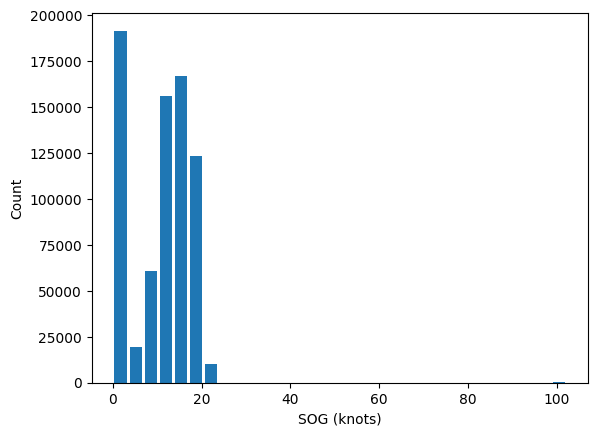

In [36]:
plt.hist(cargo_ais_meta_merged["speed_over_ground"], rwidth=0.8, bins=30)
plt.xlabel("SOG (knots)")
plt.ylabel("Count")
plt.show()

We also have lots of entries with SOG of 0, keep them as is for now and just remove  the upper 1% quantile outliers.

In [37]:

upper_q = 0.99

q_high = cargo_ais_meta_merged["speed_over_ground"].quantile(upper_q)

mask = cargo_ais_meta_merged["speed_over_ground"] <= q_high
cargo_ais_meta_merged = cargo_ais_meta_merged[mask]

In [38]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    721127.000000
mean         10.415342
std           6.766939
min           0.000000
25%           2.000000
50%          12.200000
75%          16.000000
max          20.799999
Name: speed_over_ground, dtype: float64

We now get way more realistic SOG values.

#### Coords

Longitude is expected to be [-180;180].

In [41]:
cargo_ais_meta_merged["longitude"].describe()

count    721127.000000
mean          2.562838
std          20.930872
min         -95.021350
25%          -3.043010
50%          -0.241067
75%           2.270973
max         123.744342
Name: longitude, dtype: float64

Latitude is expected to be [-90;90].

In [42]:
cargo_ais_meta_merged["latitude"].describe()

count    721127.000000
mean         30.283610
std          19.613514
min         -35.536462
25%          34.843748
50%          38.614202
75%          39.404062
max          60.196253
Name: latitude, dtype: float64

No impossible coords detected.

## Feature engineering

#### Calculate course deviation and include as feature<br>
Vessel can't deviate by more than 360 degrees total, so map to -180,180 degrees.

In [58]:
diff = cargo_ais_meta_merged["course_over_ground"] - cargo_ais_meta_merged["true_heading"]
cargo_ais_meta_merged["deg_off_course"] = ((diff + 180) % 360) - 180
cargo_ais_meta_merged["deg_off_course"].describe()

count    721127.000000
mean         -0.130647
std          52.360921
min        -180.000000
25%          -2.000000
50%           0.099998
75%           2.299988
max         179.900002
Name: deg_off_course, dtype: float64

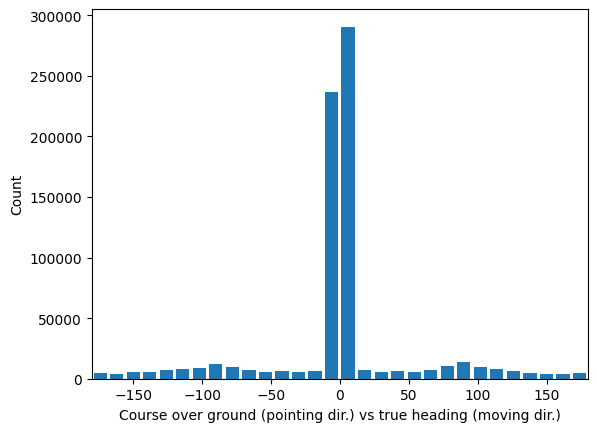

In [65]:
plt.hist(cargo_ais_meta_merged["deg_off_course"], rwidth=0.8, bins=30)
plt.xlim(-180, 180)
plt.xlabel("Course over ground (pointing dir.) vs true heading (moving dir.)")
plt.ylabel("Count")
plt.show()

### Include time-to-arrival (TTA) as feature (arrival time - timestamp)

In [62]:
cargo_ais_meta_merged["tta"] = cargo_ais_meta_merged["arrival_time"] - cargo_ais_meta_merged["pos_timestamp"]
cargo_ais_meta_merged["tta"].describe()

count                       721127
mean     4 days 06:29:01.643413920
std      6 days 04:34:34.508494246
min                0 days 00:02:00
25%         0 days 11:16:10.500000
50%                1 days 15:25:11
75%                4 days 22:37:00
max        46 days 06:23:19.178000
Name: tta, dtype: object

In [44]:
cargo_ais_meta_merged["tta_hours"] = cargo_ais_meta_merged["tta"].dt.total_seconds() / 3600
cargo_ais_meta_merged["tta_hours"].describe().round(2)

count    721127.00
mean        102.48
std         148.58
min           0.03
25%          11.27
50%          39.42
75%         118.62
max        1110.39
Name: tta_hours, dtype: float64

### Drop immediately unnecessary columns

"capacity_liquid_oil", "capacity_liquid_gas" always 0, remove

In [46]:
cargo_ais_meta_merged["capacity_liquid_gas"].describe()

count    721127.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: capacity_liquid_gas, dtype: float64

In [47]:
cargo_ais_meta_merged["capacity_liquid_oil"].describe()

count    721127.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: capacity_liquid_oil, dtype: float64

In [48]:
unrelated_cols = ["capacity_liquid_gas", "capacity_liquid_oil", "arrival_country", "meta_source", "imo", "arrival_locode", "owner", "name", "manager", "builder", "destination", "class_society", "flag", "vid_prefix", "next_voyage_id", "prev_voyage_id", "departed_port_call_id", "arrived_port_call_id", "call_sign", "ref_point_a", "ref_point_b", "ref_point_c", "ref_point_d", "call_sign"]
cargo_ais_meta_merged.drop(columns=unrelated_cols, inplace=True)

In [49]:
cargo_ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'ship_type',
       'position_device', 'eta', 'draught', 'meta_timestamp', 'build_year',
       'length', 'width', 'capacity_dwt', 'capacity_gt', 'capacity_teu',
       'capacity_passenger', 'commercial_size_class', 'vessel_type_details',
       'draught_max', 'draught_min', 'capacity_nt', 'month', 'departure_time',
       'departure_locode', 'departure_latitude', 'departure_longitude',
       'arrival_time', 'arrival_latitude', 'arrival_longitude', 'duration',
       'arrival_date', 'tta', 'tta_hours'],
      dtype='object')

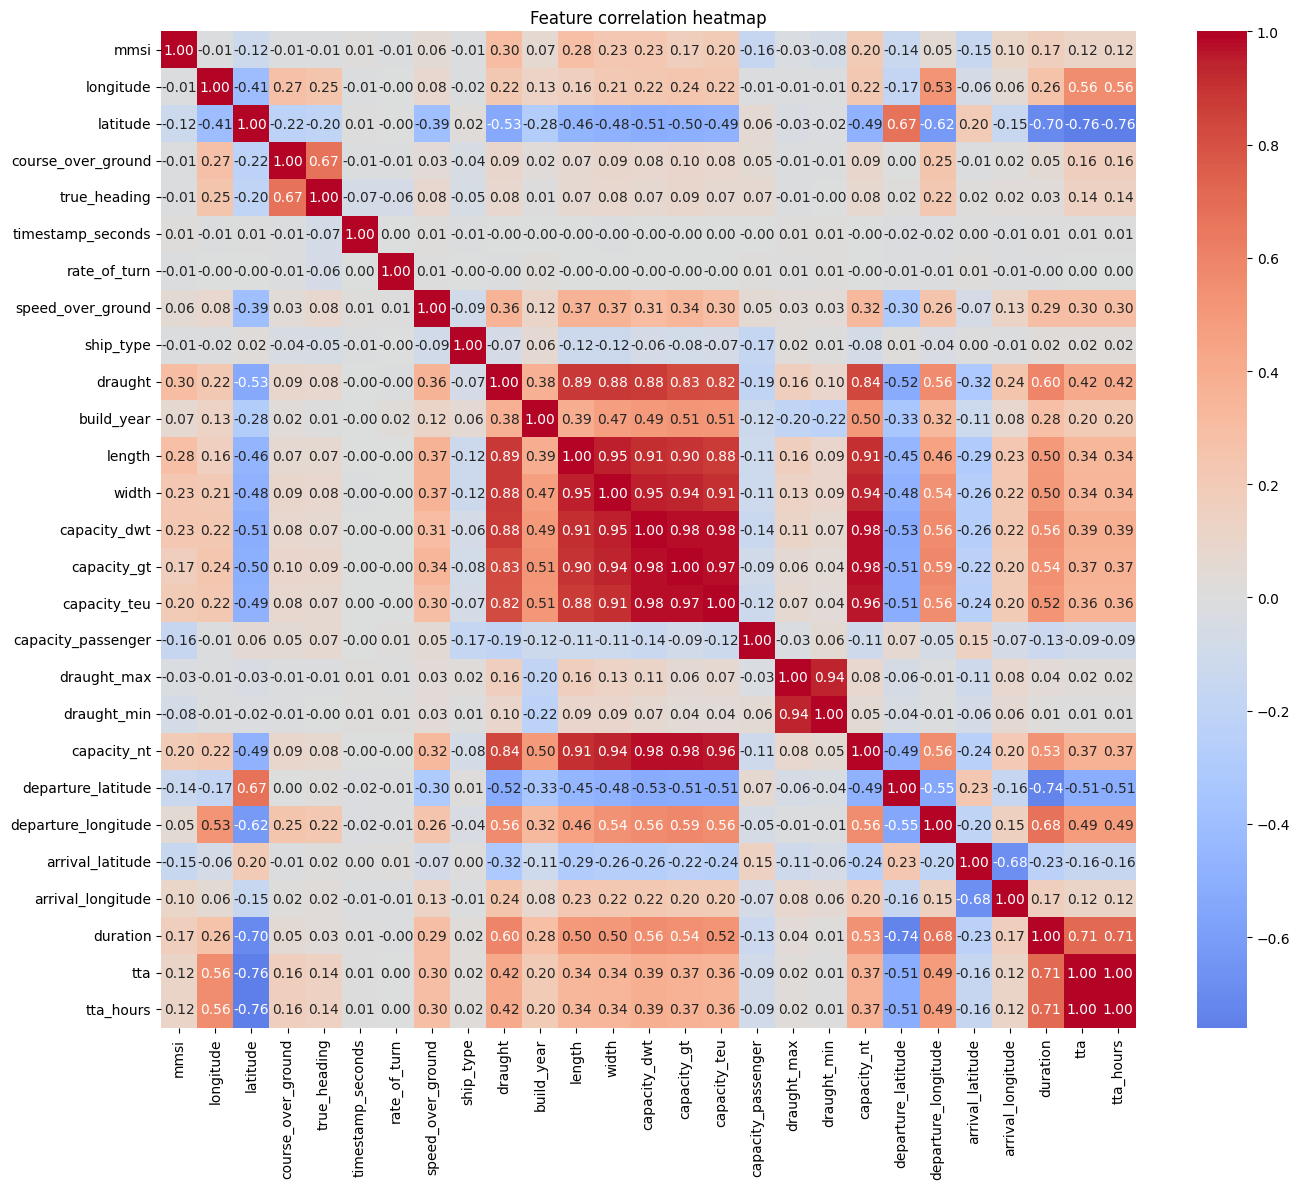

In [53]:
# seaborn correlation heatmap
import seaborn as sns

# 1) Select only numeric columns from your df (e.g. X_train)
num_df = cargo_ais_meta_merged.select_dtypes(include=["number"])

# 2) Compute correlation matrix
corr = num_df.corr()

# 3) Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

## Model development

In [ ]:
drop_cols = [
    # IDs / bookkeeping
    "voyage_id", "meta_timestamp", "mmsi", 
    # future / label leakage
    "departure_time", "arrival_time", "arrival_date",
    "departure_latitude", "departure_longitude",
    "arrival_latitude", "arrival_longitude",
    "eta", "duration", "tta", "tta_hours",
    # redundant capacity/size
    # "capacity_ng", "commercial_size_class",
    # maybe redundant draught stats for v1
    # "draught_max", "draught_min",
    # choose one of heading / course, here keep course_over_ground
    "true_heading",
    # redundant (raw datetime, have timestamp_seconds)
    "pos_timestamp",
]

X = cargo_ais_meta_merged.drop(columns=drop_cols)
y = cargo_ais_meta_merged["tta_hours"]

In [ ]:
X.columns

In [ ]:
# 1) Clean label first
df_model = cargo_ais_meta_merged.copy()
df_model = df_model[~df_model["tta_hours"].isna()]

# 2) Sort by time
df_model = df_model.sort_values("pos_timestamp")

# 3) Build X, y
X = df_model.drop(columns=drop_cols)
y = df_model["tta_hours"]

# 4) Time-based split
split_idx = int(len(df_model) * 0.8)
X_train_full, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_full, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

# 5) Subsample 1k from the training part
n_sub = 1000
X_train = X_train_full.iloc[:n_sub].copy()
y_train = y_train_full.iloc[:n_sub].copy()


In [ ]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

cat_cols, num_cols

In [ ]:
# Example: drop raw datetimes from X
date_like_cols = X_train.select_dtypes(include=["datetime64[ns]", "timedelta64[ns]"]).columns
date_like_cols
X_train = X_train.drop(columns=date_like_cols)
X_val   = X_val.drop(columns=date_like_cols)


In [ ]:
X_train.dtypes.head()

In [ ]:
X_train.shape

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category", "bool"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    n_jobs=28,
    random_state=42,
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf),
])

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category", "bool"]).columns.tolist()

# 1) Scale NUMERICS only, passthrough CATEGORICALS
preprocess_scale = ColumnTransformer(
    transformers=[
        ("cat", "passthrough", cat_cols),           # don't touch categoricals yet
        ("num", Normalizer(), num_cols),        # scale numerics only
    ]
)

# 2) Now one-hot + combine + PCA + RF
model = Pipeline(steps=[
    ("preprocess_scale", preprocess_scale),
    ("encode_cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),  # dense output
    ("pca", PCA(n_components=0.9)),
    ("rf", RandomForestRegressor(n_estimators=200, n_jobs=28, random_state=42))
])


In [ ]:
model.fit(X_train, y_train)

## Model evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Predictions on validation set
y_pred = model.predict(X_val)

# 2) Core regression metrics
mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)

print(f"MAE (hours):  {mae:.2f}")
print(f"RMSE (hours): {rmse:.2f}")
print(f"R²:           {r2:.5f}")

# 3) Optional: quick sanity check of errors
errors = y_pred - y_val
print(errors.describe())

In [ ]:
import joblib
joblib.dump(model, "model1.joblib")

In [ ]:
import joblib
model = joblib.load("model1.joblib")